In [1]:
!pip install duckdb

In [3]:
import pandas as pd
import numpy as np
import duckdb
import os

import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
file_list = [
    "Statcast_2018.csv",
    "Statcast_2019.csv",
    "Statcast_2020.csv",
    "Statcast_2021.csv"
]

# Columns to keep
columns_to_keep = [
    "batter",
    "player_name",
    "game_year",
    "launch_speed",
    "launch_angle",
    "hit_distance_sc",
    "bb_type",
    "events",
    "estimated_woba_using_speedangle",
    "woba_value",
    "babip_value",
    "at_bat_number",
    "pitch_number"
]

# Load and combine
df_all = []

for file in file_list:
    temp = pd.read_csv(file, usecols=columns_to_keep)
    df_all.append(temp)

df = pd.concat(df_all, ignore_index=True)

print("Combined dataset shape:", df.shape)

Combined dataset shape: (2428261, 13)


In [23]:
print("New shape:", df.shape)
print("\nColumns kept:")
print(df.columns.tolist())

display(df.head())

New shape: (2428261, 13)

Columns kept:
['player_name', 'batter', 'events', 'bb_type', 'game_year', 'hit_distance_sc', 'launch_speed', 'launch_angle', 'estimated_woba_using_speedangle', 'woba_value', 'babip_value', 'at_bat_number', 'pitch_number']


,player_name,batter,events,bb_type,game_year,hit_distance_sc,launch_speed,launch_angle,estimated_woba_using_speedangle,woba_value,babip_value,at_bat_number,pitch_number
0,"Jansen, Kenley",467827,strikeout,NaN,2018,NaN,NaN,NaN,NaN,0.0,0.0,71,4
1,"Jansen, Kenley",467827,NaN,NaN,2018,NaN,NaN,NaN,NaN,NaN,NaN,71,3
2,"Jansen, Kenley",467827,NaN,NaN,2018,NaN,NaN,NaN,NaN,NaN,NaN,71,2
3,"Jansen, Kenley",467827,NaN,NaN,2018,NaN,NaN,NaN,NaN,NaN,NaN,71,1
4,"Jansen, Kenley",435622,strikeout,NaN,2018,NaN,NaN,NaN,NaN,0.0,0.0,70,6


In [24]:
# Keep only batted ball events
df_contact = df[df["bb_type"].notna()].copy()

print("Original rows:", df.shape[0])
print("Batted ball rows:", df_contact.shape[0])

display(df_contact.head())

Original rows: 2428261
Batted ball rows: 417902


,player_name,batter,events,bb_type,game_year,hit_distance_sc,launch_speed,launch_angle,estimated_woba_using_speedangle,woba_value,babip_value,at_bat_number,pitch_number
10,"Jansen, Kenley",471865,field_out,ground_ball,2018,4.0,79.9,-33.0,0.081,0.0,0.0,69,1
11,"Jansen, Kenley",596115,home_run,fly_ball,2018,409.0,104.7,24.0,1.737,2.0,0.0,68,9
20,"Jansen, Kenley",571448,home_run,fly_ball,2018,414.0,107.1,23.0,1.780,2.0,0.0,67,1
21,"Johnson, DJ",571771,field_out,ground_ball,2018,10.0,81.0,-11.0,0.072,0.0,0.0,66,1
22,"McGee, Jake",624577,field_out,ground_ball,2018,8.0,65.7,-16.0,0.070,0.0,0.0,65,2


In [25]:
print("\nMissing launch_speed %:", df_contact["launch_speed"].isna().mean())
print("Missing launch_angle %:", df_contact["launch_angle"].isna().mean())


Missing launch_speed %: 0.01183770357643658
Missing launch_angle %: 0.01201238567893908


In [26]:
player_season_statcast = (
    df_contact
    .groupby(["batter", "game_year"])
    .agg(
        balls_in_play=("bb_type", "count"),

        avg_exit_velocity=("launch_speed", "mean"),
        avg_launch_angle=("launch_angle", "mean"),
        avg_hit_distance=("hit_distance_sc", "mean"),

        max_exit_velocity=("launch_speed", "max"),

        avg_xwoba=("estimated_woba_using_speedangle", "mean"),

        ground_ball_rate=("bb_type", lambda x: (x == "ground_ball").mean()),
        line_drive_rate=("bb_type", lambda x: (x == "line_drive").mean()),
        fly_ball_rate=("bb_type", lambda x: (x == "fly_ball").mean()),
        popup_rate=("bb_type", lambda x: (x == "popup").mean()),
    )
    .reset_index()
)

In [27]:
print("Shape of player-season statcast table:", player_season_statcast.shape)

display(player_season_statcast.head())

Shape of player-season statcast table: (3342, 12)


,batter,game_year,balls_in_play,avg_exit_velocity,avg_launch_angle,avg_hit_distance,max_exit_velocity,avg_xwoba,ground_ball_rate,line_drive_rate,fly_ball_rate,popup_rate
0,112526,2018,1,76.900000,-30.000000,4.000000,76.9,0.081000,1.000000,0.000000,0.000000,0.000000
1,134181,2018,345,88.697674,13.633721,187.429907,109.2,0.382826,0.391304,0.301449,0.255072,0.052174
2,282332,2019,1,96.800000,17.000000,297.000000,96.8,0.476000,0.000000,1.000000,0.000000,0.000000
3,400085,2018,37,81.311111,5.722222,125.571429,100.1,0.219333,0.567568,0.135135,0.216216,0.081081
4,400085,2019,4,NaN,NaN,NaN,NaN,NaN,0.500000,0.000000,0.000000,0.500000


In [28]:
print("\nSummary stats:")
print(player_season_statcast.describe())

print("\nCheck for duplicates:")
print(player_season_statcast.duplicated(subset=["batter", "game_year"]).sum())


Summary stats:
              batter    game_year  balls_in_play  avg_exit_velocity  \
count    3342.000000  3342.000000    3342.000000        3312.000000   
mean   584344.368043  2019.465290     125.045482          85.097785   
std     68886.565717     1.166154     142.042078           8.927438   
min    112526.000000  2018.000000       1.000000          15.800000   
25%    543308.000000  2018.000000      10.000000          83.757500   
50%    599096.000000  2019.000000      64.000000          87.219368   
75%    641791.250000  2021.000000     196.000000          89.550629   
max    685503.000000  2021.000000     573.000000         109.600000   

       avg_launch_angle  avg_hit_distance  max_exit_velocity    avg_xwoba  \
count       3312.000000       3299.000000        3312.000000  3312.000000   
mean           7.516467        146.057254         103.706884     0.325824   
std           15.728723         58.299768          12.255676     0.120515   
min          -82.000000          0.0

In [29]:
# Create player-season batting outcomes

# First, define helper functions
def is_hit(x):
    return x in ["single", "double", "triple", "home_run"]

def is_ab(x):
    # At-bats exclude walks, hit by pitch, etc.
    return x not in ["walk", "hit_by_pitch", "sac_bunt", "sac_fly"]

# Apply flags
df["is_hit"] = df["events"].apply(lambda x: is_hit(x) if pd.notna(x) else False)
df["is_ab"] = df["events"].apply(lambda x: is_ab(x) if pd.notna(x) else False)

# Aggregate to player-season
player_season_batting = (
    df
    .groupby(["batter", "game_year"])
    .agg(
        plate_appearances=("events", "count"),
        hits=("is_hit", "sum"),
        at_bats=("is_ab", "sum"),
        home_runs=("events", lambda x: (x == "home_run").sum()),
        strikeouts=("events", lambda x: (x == "strikeout").sum()),
        walks=("events", lambda x: (x == "walk").sum()),
    )
    .reset_index()
)

# Create batting average
player_season_batting["batting_avg"] = (
    player_season_batting["hits"] / player_season_batting["at_bats"]
)

print("Shape:", player_season_batting.shape)
display(player_season_batting.head())

Shape: (3610, 9)


,batter,game_year,plate_appearances,hits,at_bats,home_runs,strikeouts,walks,batting_avg
0,112526,2018,4,0,4,0,3,0,0.000000
1,134181,2018,479,118,434,15,95,32,0.271889
2,282332,2019,3,0,3,0,2,0,0.000000
3,400085,2018,47,9,44,0,7,3,0.204545
4,400085,2019,6,0,5,0,1,1,0.000000


In [30]:
print("\nCheck duplicates:")
print(player_season_batting.duplicated(subset=["batter", "game_year"]).sum())

print("\nSummary:")
print(player_season_batting.describe())


Check duplicates:
0

Summary:
              batter    game_year  plate_appearances         hits  \
count    3610.000000  3610.000000         3610.00000  3610.000000   
mean   585604.224654  2019.467867          171.34072    37.960111   
std     68567.811090     1.174304          199.86953    48.295239   
min    112526.000000  2018.000000            1.00000     0.000000   
25%    543380.500000  2018.000000            9.00000     1.000000   
50%    601713.000000  2019.000000           76.00000    14.000000   
75%    641899.750000  2021.000000          265.00000    59.000000   
max    685503.000000  2021.000000          745.00000   206.000000   

           at_bats    home_runs   strikeouts        walks  batting_avg  
count  3610.000000  3610.000000  3610.000000  3610.000000  3583.000000  
mean    153.580332     5.711357    39.159557    14.099446     0.185366  
std     179.040017     8.785130    43.386035    19.149145     0.127046  
min       0.000000     0.000000     0.000000     0.0000

In [31]:
# Merge predictor and outcome tables
model_df = pd.merge(
    player_season_statcast,
    player_season_batting,
    on=["batter", "game_year"],
    how="inner"
)

print("Model dataset shape:", model_df.shape)
display(model_df.head())

Model dataset shape: (3342, 19)


,batter,game_year,balls_in_play,avg_exit_velocity,avg_launch_angle,avg_hit_distance,max_exit_velocity,avg_xwoba,ground_ball_rate,line_drive_rate,fly_ball_rate,popup_rate,plate_appearances,hits,at_bats,home_runs,strikeouts,walks,batting_avg
0,112526,2018,1,76.900000,-30.000000,4.000000,76.9,0.081000,1.000000,0.000000,0.000000,0.000000,4,0,4,0,3,0,0.000000
1,134181,2018,345,88.697674,13.633721,187.429907,109.2,0.382826,0.391304,0.301449,0.255072,0.052174,479,118,434,15,95,32,0.271889
2,282332,2019,1,96.800000,17.000000,297.000000,96.8,0.476000,0.000000,1.000000,0.000000,0.000000,3,0,3,0,2,0,0.000000
3,400085,2018,37,81.311111,5.722222,125.571429,100.1,0.219333,0.567568,0.135135,0.216216,0.081081,47,9,44,0,7,3,0.204545
4,400085,2019,4,NaN,NaN,NaN,NaN,NaN,0.500000,0.000000,0.000000,0.500000,6,0,5,0,1,1,0.000000


In [32]:
print("\nDuplicates in model dataset:")
print(model_df.duplicated(subset=["batter", "game_year"]).sum())

print("\nMissing values by column:")
print(model_df.isna().sum())

print("\nSummary of batting_avg:")
print(model_df["batting_avg"].describe())


Duplicates in model dataset:
0

Missing values by column:
batter                0
game_year             0
balls_in_play         0
avg_exit_velocity    30
avg_launch_angle     30
avg_hit_distance     43
max_exit_velocity    30
avg_xwoba            30
ground_ball_rate      0
line_drive_rate       0
fly_ball_rate         0
popup_rate            0
plate_appearances     0
hits                  0
at_bats               0
home_runs             0
strikeouts            0
walks                 0
batting_avg          18
dtype: int64

Summary of batting_avg:
count    3324.000000
mean        0.199810
std         0.120465
min         0.000000
25%         0.145323
50%         0.222222
75%         0.261545
max         1.000000
Name: batting_avg, dtype: float64


In [33]:
# Filter to qualified hitters
model_df_filtered = model_df[
    (model_df["plate_appearances"] >= 100) &
    (model_df["balls_in_play"] >= 50)
].copy()

print("Original model size:", model_df.shape)
print("Filtered model size:", model_df_filtered.shape)

display(model_df_filtered.head())

Original model size: (3342, 19)
Filtered model size: (1671, 19)


,batter,game_year,balls_in_play,avg_exit_velocity,avg_launch_angle,avg_hit_distance,max_exit_velocity,avg_xwoba,ground_ball_rate,line_drive_rate,fly_ball_rate,popup_rate,plate_appearances,hits,at_bats,home_runs,strikeouts,walks,batting_avg
1,134181,2018,345,88.697674,13.633721,187.429907,109.2,0.382826,0.391304,0.301449,0.255072,0.052174,479,118,434,15,95,32,0.271889
5,400121,2018,425,87.743632,13.981132,180.596354,107.6,0.333219,0.416471,0.265882,0.249412,0.068235,506,117,469,9,47,28,0.249467
6,400284,2018,131,87.292857,16.547619,177.906780,106.4,0.303603,0.427481,0.244275,0.274809,0.053435,185,35,164,1,34,15,0.213415
7,405395,2018,403,90.028288,14.148883,178.812155,112.1,0.365859,0.409429,0.263027,0.225806,0.101737,495,114,465,19,65,25,0.245161
8,405395,2019,431,88.294340,12.547170,166.576227,112.3,0.341953,0.461717,0.169374,0.266821,0.102088,544,120,491,23,68,42,0.244399


In [34]:
print("\nNew batting_avg summary:")
print(model_df_filtered["batting_avg"].describe())


New batting_avg summary:
count    1671.000000
mean        0.245833
std         0.037783
min         0.117188
25%         0.222222
50%         0.248092
75%         0.270833
max         0.370629
Name: batting_avg, dtype: float64


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Select features (X) and target (y)

features = [
    "avg_exit_velocity",
    "avg_launch_angle",
    "avg_hit_distance",
    "max_exit_velocity",
    "avg_xwoba",
    "ground_ball_rate",
    "line_drive_rate",
    "fly_ball_rate",
    "popup_rate"
]

X = model_df_filtered[features]
y = model_df_filtered["batting_avg"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R^2:", r2)

MSE: 0.0012255928897853135
R^2: 0.21593389290425868


In [38]:
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

print("\nFeature Importance (Linear Coefficients):")
display(coef_df)


Feature Importance (Linear Coefficients):


,Feature,Coefficient
6,line_drive_rate,0.231040
4,avg_xwoba,0.116484
0,avg_exit_velocity,0.001696
3,max_exit_velocity,0.000302
2,avg_hit_distance,-0.000010
1,avg_launch_angle,-0.001318
5,ground_ball_rate,-0.052279
7,fly_ball_rate,-0.080560
8,popup_rate,-0.098201


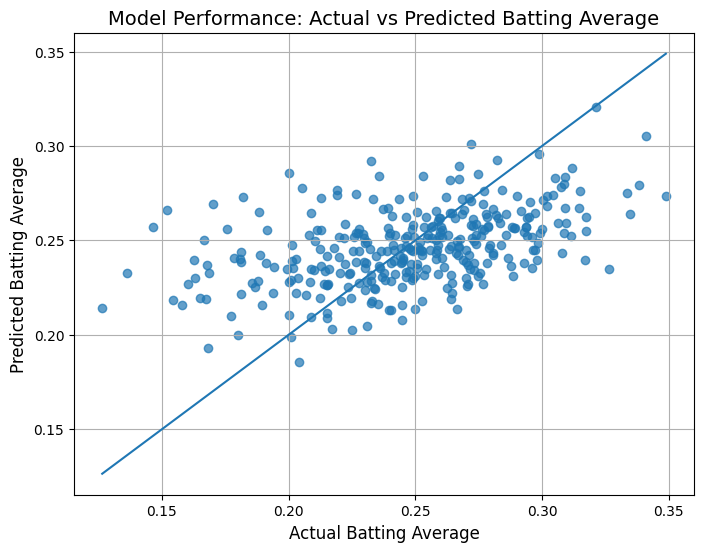

In [39]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
)

plt.xlabel("Actual Batting Average", fontsize=12)
plt.ylabel("Predicted Batting Average", fontsize=12)
plt.title("Model Performance: Actual vs Predicted Batting Average", fontsize=14)

plt.grid(True)

plt.show()

In [40]:
## Save Final Relational Tables
players = model_df_filtered[["batter"]].drop_duplicates().copy()
players["player_id"] = players["batter"]

players = players[["player_id"]]

print(players.shape)
display(players.head())

(677, 1)


,player_id
1,134181
5,400121
6,400284
7,405395
13,408045


In [41]:
seasons = model_df_filtered[["game_year"]].drop_duplicates().copy()
seasons = seasons.rename(columns={"game_year": "season"})

print(seasons.shape)
display(seasons)

(4, 1)


,season
1,2018
8,2019
9,2020
10,2021


In [42]:
player_season_statcast_final = model_df_filtered[
    [
        "batter",
        "game_year",
        "balls_in_play",
        "avg_exit_velocity",
        "avg_launch_angle",
        "avg_hit_distance",
        "max_exit_velocity",
        "avg_xwoba",
        "ground_ball_rate",
        "line_drive_rate",
        "fly_ball_rate",
        "popup_rate"
    ]
].copy()

In [43]:
player_season_batting_final = model_df_filtered[
    [
        "batter",
        "game_year",
        "plate_appearances",
        "hits",
        "at_bats",
        "home_runs",
        "strikeouts",
        "walks",
        "batting_avg"
    ]
].copy()

In [45]:
import os

os.makedirs("data/final", exist_ok=True)

players.to_csv("data/final/players.csv", index=False)
seasons.to_csv("data/final/seasons.csv", index=False)
player_season_statcast_final.to_csv("data/final/player_season_statcast.csv", index=False)
player_season_batting_final.to_csv("data/final/player_season_batting.csv", index=False)

print("All tables saved!")

All tables saved!


In [46]:
## Load Data into DuckDB
import duckdb

# Create connection (in-memory)
con = duckdb.connect()

print("DuckDB connected")

DuckDB connected


In [47]:
# Load tables into DuckDB

con.execute("""
CREATE TABLE players AS
SELECT * FROM read_csv_auto('data/final/players.csv')
""")

con.execute("""
CREATE TABLE seasons AS
SELECT * FROM read_csv_auto('data/final/seasons.csv')
""")

con.execute("""
CREATE TABLE player_season_statcast AS
SELECT * FROM read_csv_auto('data/final/player_season_statcast.csv')
""")

con.execute("""
CREATE TABLE player_season_batting AS
SELECT * FROM read_csv_auto('data/final/player_season_batting.csv')
""")

print("Tables loaded into DuckDB")

Tables loaded into DuckDB


In [48]:
print(con.execute("SHOW TABLES").fetchall())

[('player_season_batting',), ('player_season_statcast',), ('players',), ('seasons',)]


In [49]:
query = """
SELECT
    s.batter,
    s.game_year,
    s.avg_exit_velocity,
    s.avg_launch_angle,
    s.avg_xwoba,
    b.batting_avg,
    b.home_runs
FROM player_season_statcast s
JOIN player_season_batting b
ON s.batter = b.batter
AND s.game_year = b.game_year
"""

result = con.execute(query).df()

print(result.shape)
display(result.head())

(1671, 7)


,batter,game_year,avg_exit_velocity,avg_launch_angle,avg_xwoba,batting_avg,home_runs
0,134181,2018,88.697674,13.633721,0.382826,0.271889,15
1,400121,2018,87.743632,13.981132,0.333219,0.249467,9
2,400284,2018,87.292857,16.547619,0.303603,0.213415,1
3,405395,2018,90.028288,14.148883,0.365859,0.245161,19
4,405395,2019,88.294340,12.547170,0.341953,0.244399,23


In [51]:
query_top = """
SELECT
    s.batter,
    s.game_year,
    s.avg_exit_velocity,
    b.batting_avg
FROM player_season_statcast s
JOIN player_season_batting b
ON s.batter = b.batter
AND s.game_year = b.game_year
ORDER BY s.avg_exit_velocity DESC
LIMIT 10
"""

top_players = con.execute(query_top).df()

display(top_players)

,batter,game_year,avg_exit_velocity,batting_avg
0,592450,2019,96.003433,0.271768
1,665487,2020,95.939024,0.275556
2,592450,2021,95.824365,0.287273
3,665489,2021,95.121907,0.311258
4,519317,2021,95.100852,0.272016
5,593934,2020,94.941414,0.205263
6,592450,2018,94.701128,0.277108
7,593934,2019,94.409009,0.246719
8,408234,2018,94.382407,0.298507
9,446334,2021,94.143850,0.260870
